In [6]:
# ============================================================
# CELL 1 - Load Data & Create Output Folders
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

folders = ["../visualizations/exploratory", "../visualizations/regression", "../visualizations/forecasting", "../visualizations/renewable_energy"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("=" * 60)
print("VISUALIZATION SETUP")
print("=" * 60)
print("Dataset shape:", df.shape)
print("Output folders created successfully.")

VISUALIZATION SETUP
Dataset shape: (1817, 16)
Output folders created successfully.


EXPLORATORY VISUALIZATIONS


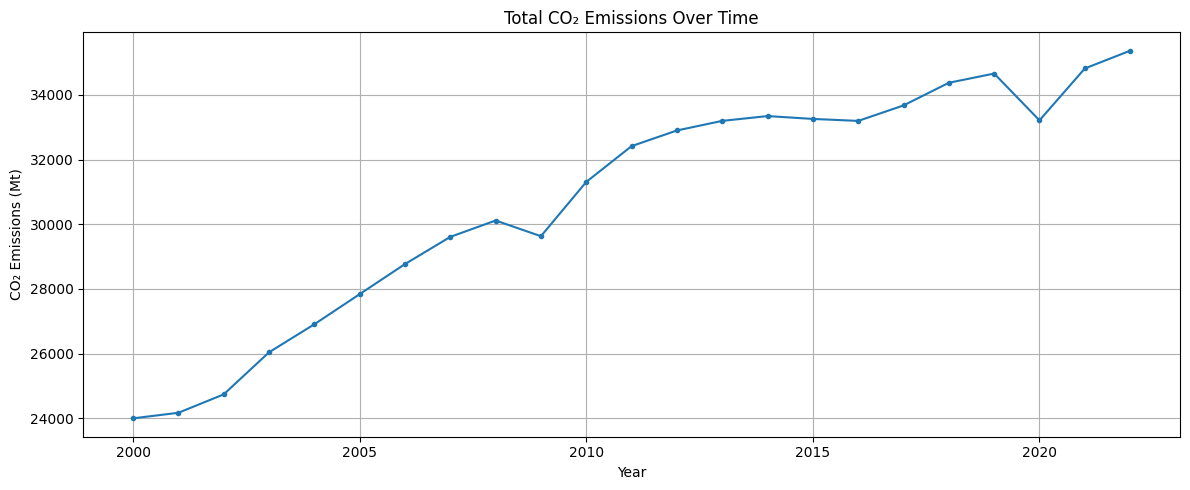

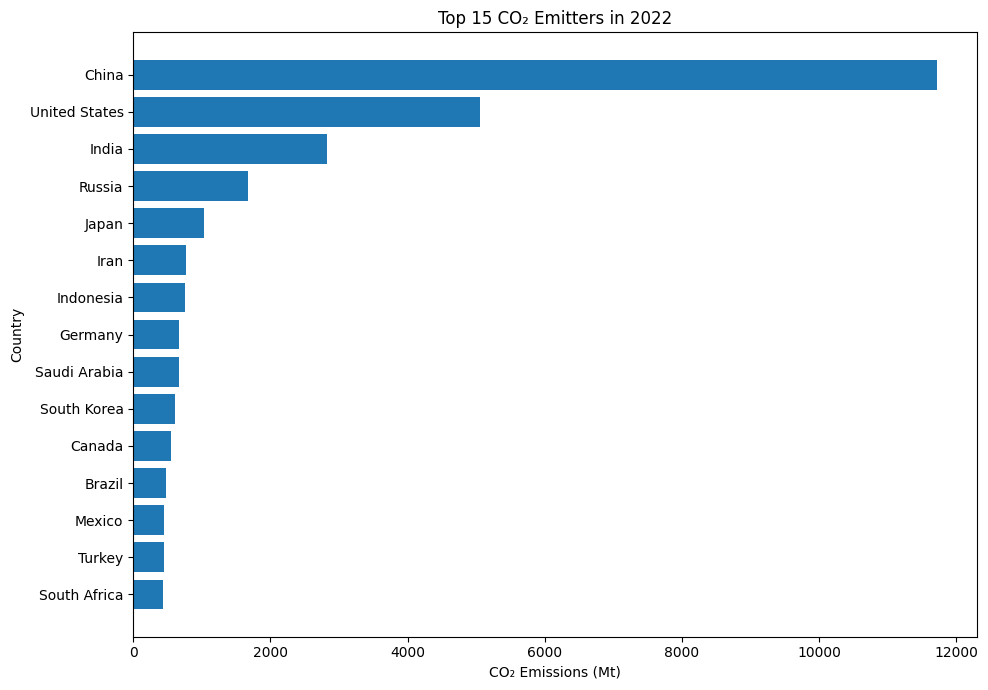

In [7]:
# ============================================================
# CELL 2 - Exploratory Visualizations
# ============================================================

print("=" * 60)
print("EXPLORATORY VISUALIZATIONS")
print("=" * 60)

yearly_co2 = df.groupby("year")["co2"].sum()

plt.figure(figsize=(12, 5))
plt.plot(yearly_co2.index, yearly_co2.values, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.title("Total CO₂ Emissions Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualizations/exploratory/co2_trend.png", dpi=300, bbox_inches="tight")
plt.show()

latest_year = df["year"].max()
latest = df[df["year"] == latest_year].nlargest(15, "co2")

plt.figure(figsize=(10, 7))
plt.barh(latest["country"][::-1], latest["co2"][::-1])
plt.xlabel("CO₂ Emissions (Mt)")
plt.ylabel("Country")
plt.title(f"Top 15 CO₂ Emitters in {latest_year}")
plt.tight_layout()
plt.savefig("../visualizations/exploratory/top_15_emitters.png", dpi=300, bbox_inches="tight")
plt.show()

REGRESSION MODEL PERFORMANCE
Model performance:


,Model,MAE,RMSE,R²
2,Gradient Boosting,22.5743,68.9022,0.9973
1,Random Forest,18.4689,85.7052,0.9959
0,Linear Regression,76.7764,135.3426,0.9898


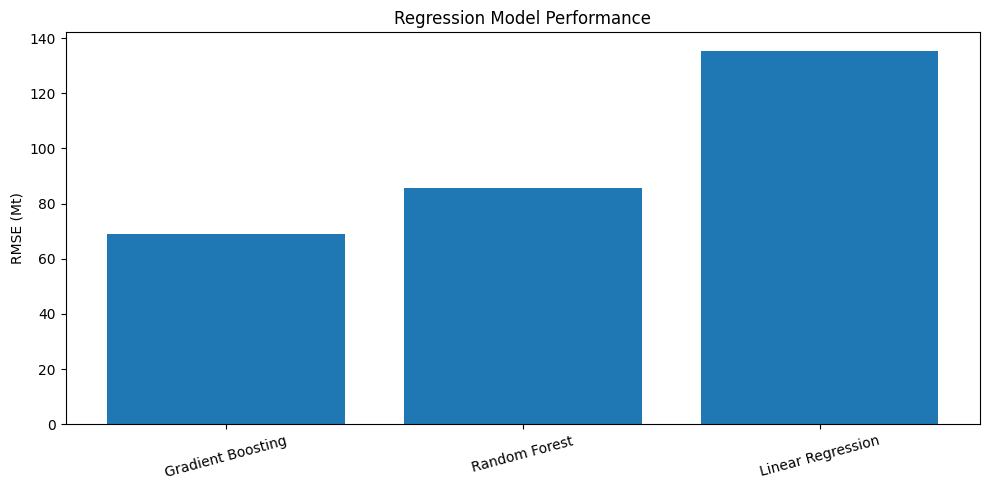

In [8]:
# ============================================================
# CELL 3 - Regression Model Performance
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("REGRESSION MODEL PERFORMANCE")
print("=" * 60)

features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy", "gdp_per_capita", "energy_per_capita"
]

X = df[features]
y = df["co2"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)

results = []

for name, pred in predictions.items():
    results.append([name, mean_absolute_error(y_test, pred), np.sqrt(mean_squared_error(y_test, pred)), r2_score(y_test, pred)])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"]).sort_values("RMSE")
print("Model performance:")
display(results.round(4))

plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE (Mt)")
plt.title("Regression Model Performance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/regression/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

BEST MODEL DIAGNOSTICS
Best model: Gradient Boosting
MAE: 22.5743
RMSE: 68.9022
R²: 0.9973


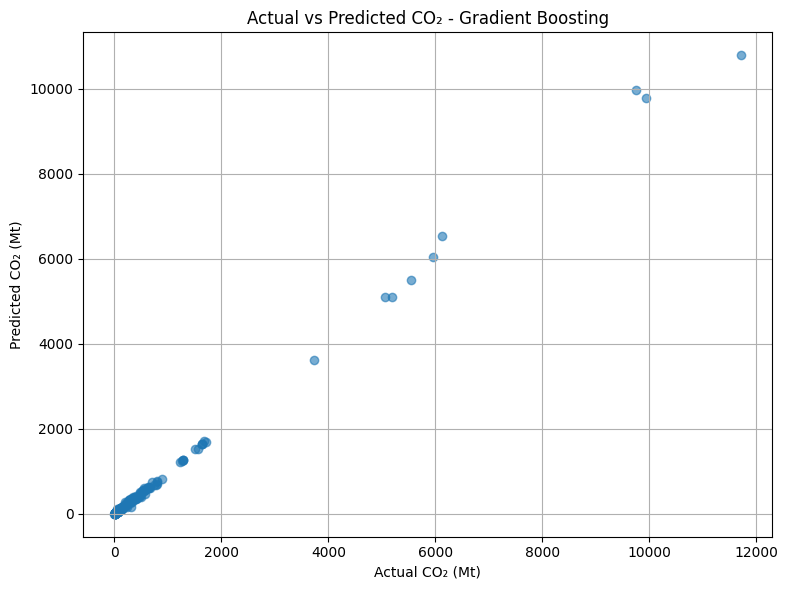

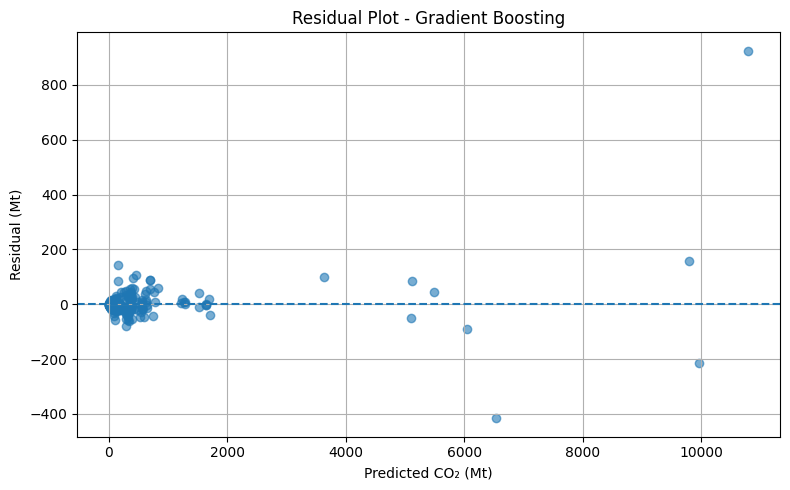

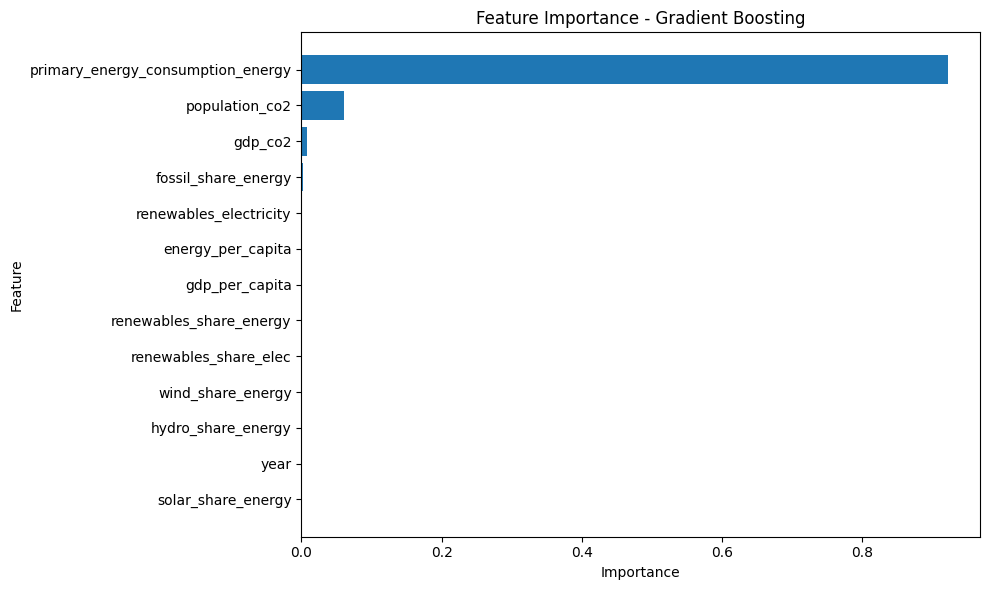

In [9]:
# ============================================================
# CELL 4 - Best Model Diagnostics
# ============================================================

print("=" * 60)
print("BEST MODEL DIAGNOSTICS")
print("=" * 60)

best_model_name = results.iloc[0]["Model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]
residuals = y_test.values - best_pred

print("Best model:", best_model_name)
print("MAE:", round(mean_absolute_error(y_test, best_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, best_pred)), 4))
print("R²:", round(r2_score(y_test, best_pred), 4))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xlabel("Actual CO₂ (Mt)")
plt.ylabel("Predicted CO₂ (Mt)")
plt.title(f"Actual vs Predicted CO₂ - {best_model_name}")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualizations/regression/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted CO₂ (Mt)")
plt.ylabel("Residual (Mt)")
plt.title(f"Residual Plot - {best_model_name}")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualizations/regression/residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
    importance_df = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.savefig("../visualizations/regression/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

FORECASTING & RENEWABLE-ENERGY VISUALIZATIONS


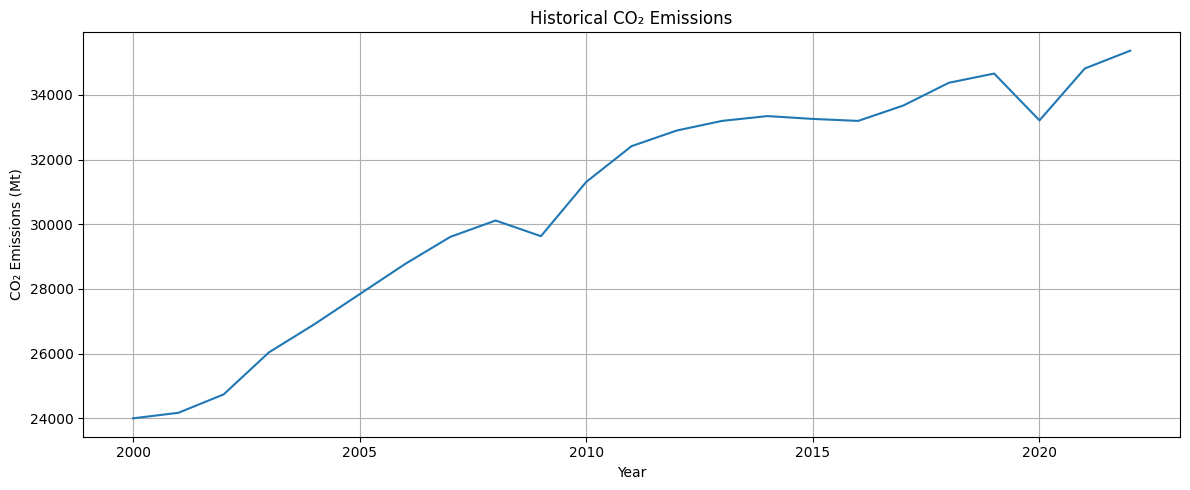

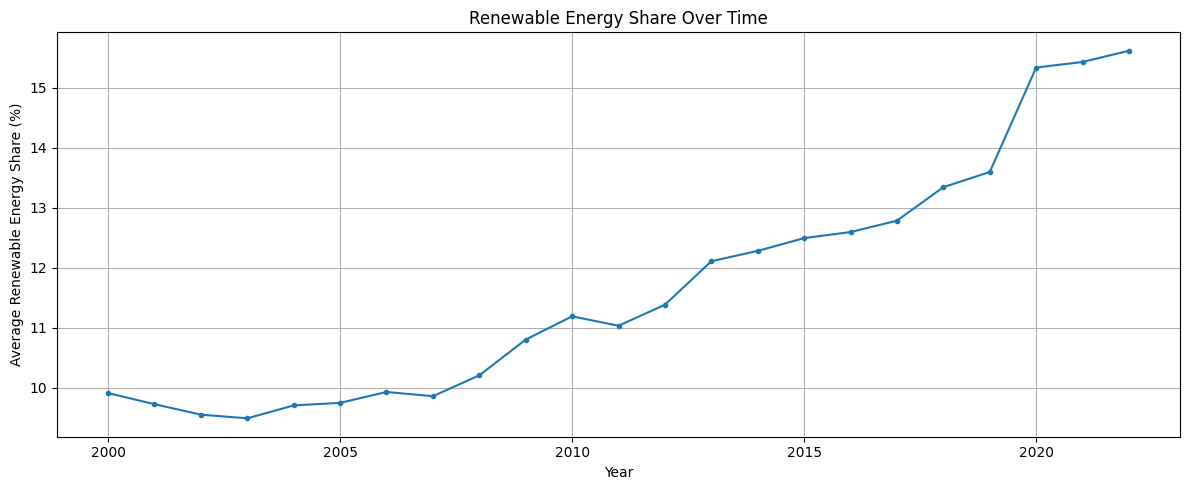

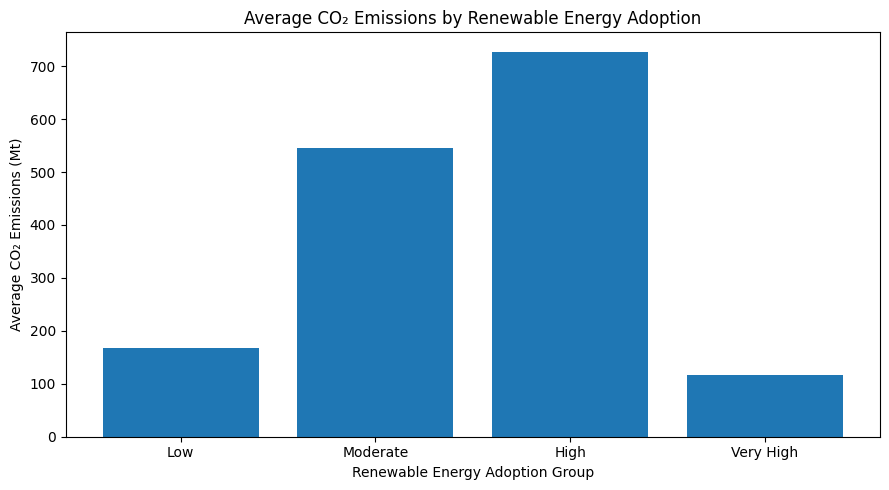


All visualization files saved successfully.


In [10]:
# ============================================================
# CELL 5 - Forecasting & Renewable-Energy Visualizations
# ============================================================

print("=" * 60)
print("FORECASTING & RENEWABLE-ENERGY VISUALIZATIONS")
print("=" * 60)

yearly = df.groupby("year").agg(
    co2=("co2", "sum"),
    renewable_share=("renewables_share_energy", "mean"),
    co2_per_capita=("co2", lambda x: np.nan)
)

co2_per_capita_yearly = df.groupby("year")["co2"].sum() / df.groupby("year")["population_co2"].sum() * 1e6

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly["co2"], label="Historical CO₂")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.title("Historical CO₂ Emissions")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualizations/forecasting/historical_co2.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.groupby("year")["renewables_share_energy"].mean().index, df.groupby("year")["renewables_share_energy"].mean().values, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("Average Renewable Energy Share (%)")
plt.title("Renewable Energy Share Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualizations/renewable_energy/renewable_share_trend.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
grouped = df.assign(
    renewable_group=pd.qcut(df["renewables_share_energy"], q=4, labels=["Low", "Moderate", "High", "Very High"])
).groupby("renewable_group", observed=True)["co2"].mean()

plt.bar(grouped.index, grouped.values)
plt.xlabel("Renewable Energy Adoption Group")
plt.ylabel("Average CO₂ Emissions (Mt)")
plt.title("Average CO₂ Emissions by Renewable Energy Adoption")
plt.tight_layout()
plt.savefig("../visualizations/renewable_energy/co2_by_renewable_group.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAll visualization files saved successfully.")